In [86]:
# Preamble
%load_ext autoreload
# %load_ext memory_profiler
%autoreload 2
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import maglab.loaders.hysteresis as l_hy
import maglab.loaders.mumax3 as l_mx3
import maglab.viz.state as v_state
import maglab.viz.colour as v_col
import maglab.processing.state as p_state

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


B_ext
m


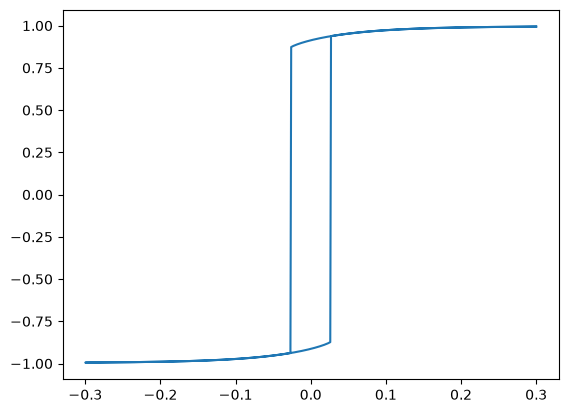

In [ ]:
DIRPATH = Path(r"C:\Users\qqhx82\OneDrive - Durham University\PhD Files\Simulations\2026-04-11 AASI Hysteresis\1-1\1-1_phi0_3.out")
df = l_hy.load_hysteresis(DIRPATH / "table.txt")
plt.plot(df["field"], df["mag"])

In [ ]:
DIRPATH = Path(r"C:\Users\qqhx82\OneDrive - Durham University\PhD Files\Simulations\2026-04-11 AASI Hysteresis\1-1\1-1_phi0_3.out")
state_idx = l_mx3.get_state_idx(DIRPATH / "table.txt")

np.int32(101)

In [2]:
DIRPATH = Path(r"C:\Users\qqhx82\OneDrive - Durham University\PhD Files\Simulations\2026-04-11 AASI Hysteresis\1-1\1-1_phi0_3.out")
# l_mx3.load_multiple_ovf_array(DIRPATH).shape

In [ ]:
indexes, fields = l_mx3.get_indexes_by_param(DIRPATH / "table.txt", values=[0.0, 0.01], vectorparam="B_ext")
arr = l_mx3.load_multiple_ovf_array(DIRPATH, indexes=[int(i) for i in indexes])



Loading OVF files: 100%|██████████| 2/2 [00:00<00:00, 745.92 files/s]


(2, 8, 148, 148, 3)

Loading OVF files: 100%|██████████| 1/1 [00:00<00:00, 259.97 files/s]


(120, 60, 3)


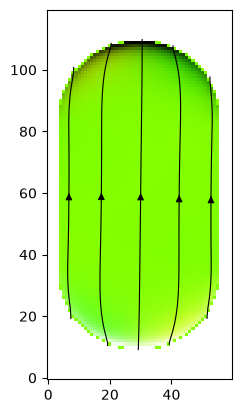

In [ ]:
# DIRPATH = Path(r"C:\Users\qqhx82\OneDrive - Durham University\PhD Files\Simulations\2026-05-21 AASI Hysteresis 2x2\5-6_phi30_3.out")
DIRPATH = Path(r"C:\Users\qqhx82\OneDrive - Durham University\PhD Files\Simulations\2026-09-17 Kunle simulations")
# indexes, fields = l_mx3.get_indexes_by_param(DIRPATH / "table.txt", values=[0.0, 0.01], vectorparam="B_ext")
indexes = None
arr = l_mx3.load_multiple_ovf_array(DIRPATH, indexes=indexes)

xy_plane = arr[0, ]

nx, ny = arr.shape[2], arr.shape[3]
# xmin, xmax = (60, 120)
# ymin, ymax = (60, 120)
# carr = p_state.select_rectangular(arr, (120, 60), (60, 120))
carr = p_state.select_rectangular(arr, (60, 120), (120, 60))



# iy, ix = np.arange(ny), np.arange(nx)
# ymask = (iy < 60) | (iy > 120)
# xmask = (ix >= 60) & (ix <= 120)
# mask2d = ymask[:, None] & xmask[None, :]

# print(arr[mask2d[None, None, :, :, None]].shape)

num = 0
zslice = 0
state_arr = carr[num, zslice, ...]
print(state_arr.shape)
ax = v_state.plot_lightness(state_arr)
v_state.plot_streamlines(state_arr, ax=ax)
v_state.to_image(ax, filepath="test.png")